# Hospital Readmission Fairness Audit
### Algorithmic Fairness, Accountability & Ethics — Spring 2026
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Protected attributes:** Race · Gender · Age  
**Target:** Readmission within 30 days

---
## Notebook Structure
- **Section 1** – Problem description & framing
- **Section 2** – Data exploration & bias analysis
- *(Sections 3–6 will be in separate notebooks)*

## 0. Environment setup

In [17]:
# Install dependencies (run once)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ucimlrepo', 'fairlearn', 'seaborn', 'matplotlib', 'pandas', 'numpy', 'scikit-learn'])

CompletedProcess(args=['c:\\Users\\yolo swaggins\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', '-q', 'ucimlrepo', 'fairlearn', 'seaborn', 'matplotlib', 'pandas', 'numpy', 'scikit-learn'], returncode=0)

In [18]:
import os

FIGURES_DIR = 'figures'
DATA_DIR = 'data'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Output folders ready: {FIGURES_DIR}/, {DATA_DIR}/')

Output folders ready: figures/, data/


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Section 1 — Problem Description & Framing

### 1.1 Why hospital readmission prediction matters

Under the US Centers for Medicare & Medicaid Services (CMS) **Hospital Readmissions Reduction Program (HRRP)**, hospitals are financially penalised for excess 30-day readmission rates. This created a strong economic incentive to deploy predictive models that flag patients at high risk of readmission so that discharge coordinators can arrange follow-up care.

**The concrete harm scenario:** A false negative — the model predicts a patient is *low*-risk when they are actually high-risk — means the clinician trusts that prediction, discharges the patient without arranging follow-up, and the patient deteriorates at home. For diabetic patients, this can mean diabetic ketoacidosis, hypoglycaemic events, or progression of comorbid conditions going undetected.

### 1.2 Who is affected and how

| Group | Potential harm | Mechanism |
|---|---|---|
| Black patients | Higher false negative rate | Structural healthcare inequity encoded in labels |
| Elderly patients | Missed high-risk flags | Age suppressed as proxy for protected status |
| Uninsured patients | Systematic under-prediction of risk | `payer_code` encodes insurance, correlates with race |

### 1.3 Access audit

| Question | Answer |
|---|---|
| Access to training data? | ✓ Yes — UCI ML Repository, publicly available |
| Access to the algorithm? | ✓ Yes — we build and train it ourselves |
| Access to predictions? | ✓ Yes — full model outputs available |
| Stated purpose? | Predict 30-day hospital readmission to guide discharge decisions |

### 1.4 Research questions

1. Does the baseline model perform equally across **racial groups**?
2. Does the baseline model perform equally across **age groups**?
3. Does the bias in performance originate from the **data** or from the **modelling**?
4. What happens to accuracy and clinical utility when we **debias**?
5. Is there an inherent **fairness–accuracy trade-off**, and where does it break down clinically?

### 1.5 Label construction decision

The original `readmitted` column has three values: `<30`, `>30`, and `NO`. We **drop rows where `readmitted = >30`** rather than collapsing them into the negative class. Rationale: a patient readmitted after 30 days represents a fundamentally different clinical outcome (not captured by CMS penalty windows) and including them as negatives would mislabel a meaningful fraction of genuinely high-risk patients, introducing label noise that would disproportionately affect groups with slower access to care.

---
## Section 2 — Data Exploration & Bias Analysis

### 2.1 Load data

In [20]:
# Fetch from UCI ML Repository (id=296 = Diabetes 130-US)
raw = fetch_ucirepo(id=296)
X = raw.data.features.copy()
y = raw.data.targets.copy()

df = pd.concat([X, y], axis=1)
print(f'Raw dataset shape: {df.shape}')
print(f'\nTarget value counts:')
print(df['readmitted'].value_counts())

c:\Users\yolo swaggins\AppData\Local\Programs\Python\Python312\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Raw dataset shape: (101766, 48)

Target value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [21]:
# ── Label construction ──────────────────────────────────────────────────────
# Drop rows where readmitted = '>30' (see Section 1.5 for justification)
df = df[df['readmitted'] != '>30'].copy()

# Binary target: 1 = readmitted within 30 days, 0 = not readmitted
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

print(f'Dataset after dropping >30 rows: {df.shape}')
print(f'\nReadmission within 30 days:')
print(df['readmitted_30'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Dataset after dropping >30 rows: (66221, 48)

Readmission within 30 days:
readmitted_30
0    82.8%
1    17.2%
Name: proportion, dtype: object


### 2.2 Basic dataset characteristics

In [22]:
print('=== Dataset Overview ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print(f'\nMissing values (top 10):')
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
display(pd.DataFrame({'Missing count': missing[missing > 0], 'Missing %': missing_pct[missing > 0]}))

=== Dataset Overview ===
Rows: 66,221   Columns: 48

Missing values (top 10):


,Missing count,Missing %
weight,64534,97.5
max_glu_serum,62811,94.9
A1Cresult,55003,83.1
medical_specialty,31733,47.9
payer_code,26428,39.9
race,1735,2.6
diag_3,1085,1.6
diag_2,284,0.4
diag_1,17,0.0


In [23]:
# Recode '?' as NaN for race and other categorical columns
df.replace('?', np.nan, inplace=True)

print('Missing values after recoding "?" as NaN:')
missing2 = df.isnull().sum().sort_values(ascending=False)
display(pd.DataFrame({'Missing count': missing2[missing2 > 0],
                      'Missing %': (missing2[missing2 > 0] / len(df) * 100).round(1)}))

Missing values after recoding "?" as NaN:


,Missing count,Missing %
weight,64534,97.5
max_glu_serum,62811,94.9
A1Cresult,55003,83.1
medical_specialty,31733,47.9
payer_code,26428,39.9
race,1735,2.6
diag_3,1085,1.6
diag_2,284,0.4
diag_1,17,0.0


### 2.3 Protected attribute distributions (Representation Bias)

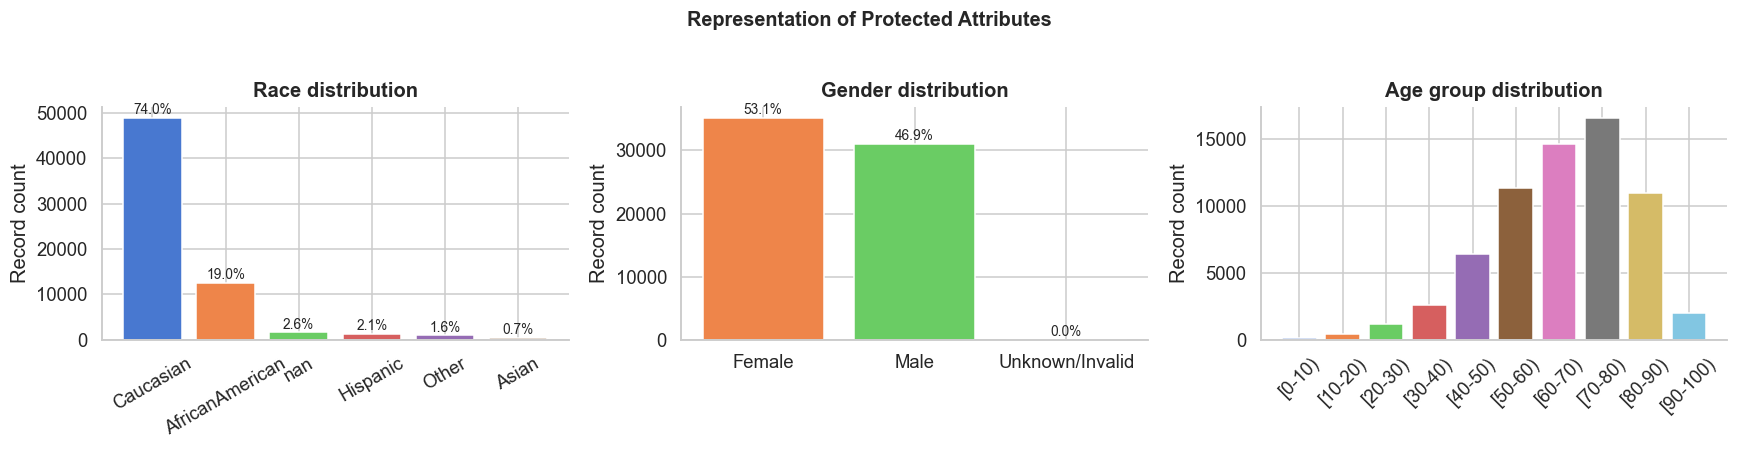

⚠ NOTE: "NaN" in race = rows where race was coded as "?" — this is itself a form of missingness bias


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Race ──────────────────────────────────────────────────────────────────
race_counts = df['race'].value_counts(dropna=False)
race_pct = race_counts / len(df) * 100

bars = axes[0].bar(race_counts.index.astype(str), race_counts.values,
                   color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Race distribution', fontweight='bold')
axes[0].set_ylabel('Record count')
axes[0].tick_params(axis='x', rotation=30)
for bar, pct in zip(bars, race_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# ── Gender ────────────────────────────────────────────────────────────────
gender_counts = df['gender'].value_counts(dropna=False)
gender_pct = gender_counts / len(df) * 100
axes[1].bar(gender_counts.index.astype(str), gender_counts.values,
            color=sns.color_palette('muted', 3)[1:], edgecolor='white')
axes[1].set_title('Gender distribution', fontweight='bold')
axes[1].set_ylabel('Record count')
for i, (bar, pct) in enumerate(zip(axes[1].patches, gender_pct.values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# ── Age ───────────────────────────────────────────────────────────────────
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_counts = df['age'].value_counts().reindex(age_order, fill_value=0)
axes[2].bar(age_counts.index, age_counts.values,
            color=sns.color_palette('muted', len(age_order)), edgecolor='white')
axes[2].set_title('Age group distribution', fontweight='bold')
axes[2].set_ylabel('Record count')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Representation of Protected Attributes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_representation.png', bbox_inches='tight')
plt.show()
print('⚠ NOTE: "NaN" in race = rows where race was coded as "?" — this is itself a form of missingness bias')

### 2.4 Readmission rates by protected attribute (Class Distribution Bias)

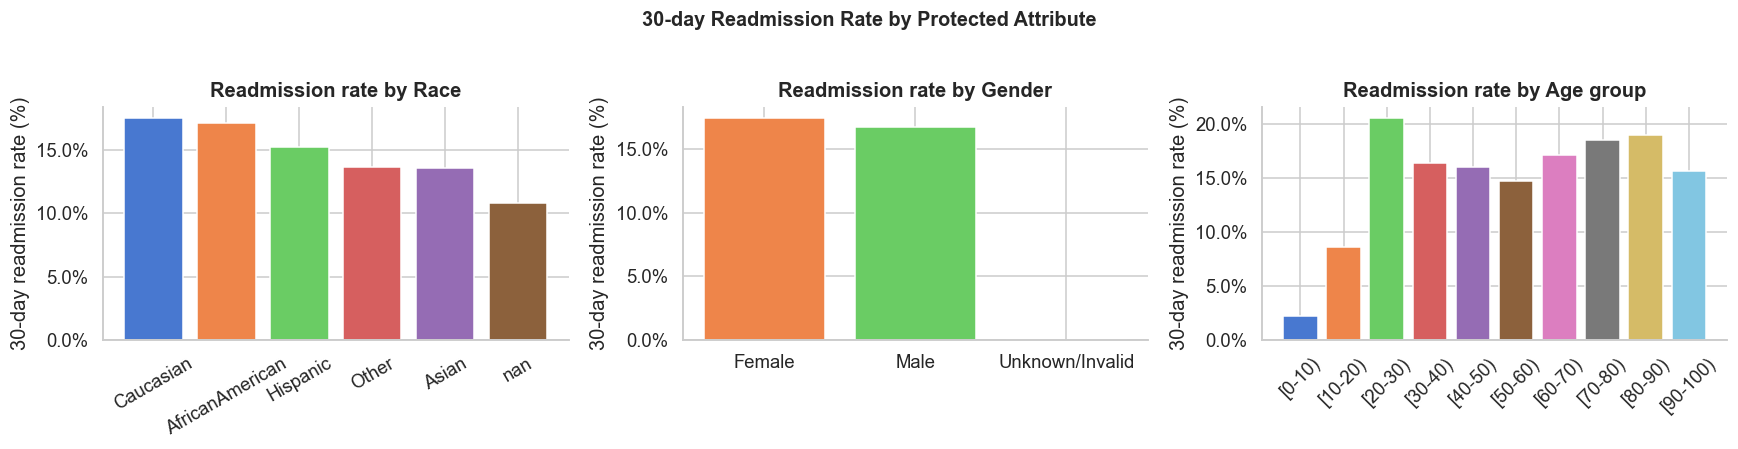

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── By race ───────────────────────────────────────────────────────────────
race_readmit = df.groupby('race', dropna=False)['readmitted_30'].agg(['mean', 'count'])
race_readmit['mean_pct'] = race_readmit['mean'] * 100
race_readmit = race_readmit.sort_values('mean_pct', ascending=False)

axes[0].bar(race_readmit.index.astype(str), race_readmit['mean_pct'],
            color=sns.color_palette('muted', len(race_readmit)), edgecolor='white')
axes[0].set_title('Readmission rate by Race', fontweight='bold')
axes[0].set_ylabel('30-day readmission rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# ── By gender ─────────────────────────────────────────────────────────────
gender_readmit = df.groupby('gender', dropna=False)['readmitted_30'].agg(['mean', 'count'])
gender_readmit['mean_pct'] = gender_readmit['mean'] * 100

axes[1].bar(gender_readmit.index.astype(str), gender_readmit['mean_pct'],
            color=sns.color_palette('muted', 3)[1:], edgecolor='white')
axes[1].set_title('Readmission rate by Gender', fontweight='bold')
axes[1].set_ylabel('30-day readmission rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# ── By age ────────────────────────────────────────────────────────────────
age_readmit = df.groupby('age', dropna=False)['readmitted_30'].agg(['mean', 'count'])
age_readmit['mean_pct'] = age_readmit['mean'] * 100
age_readmit = age_readmit.reindex(age_order)

axes[2].bar(age_readmit.index.astype(str), age_readmit['mean_pct'],
            color=sns.color_palette('muted', len(age_order)), edgecolor='white')
axes[2].set_title('Readmission rate by Age group', fontweight='bold')
axes[2].set_ylabel('30-day readmission rate (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('30-day Readmission Rate by Protected Attribute', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_readmission_rates.png', bbox_inches='tight')
plt.show()

In [26]:
# Print summary table with group sizes for representation context
print('=== Readmission Rate Summary by Race ===')
display(race_readmit[['count', 'mean_pct']].rename(columns={'count': 'N records', 'mean_pct': 'Readmission rate (%)'}).round(2))

print('\n=== Readmission Rate Summary by Age ===')
display(age_readmit[['count', 'mean_pct']].rename(columns={'count': 'N records', 'mean_pct': 'Readmission rate (%)'}).round(2))

=== Readmission Rate Summary by Race ===


,N records,Readmission rate (%)
race,,
Caucasian,48975,17.54
AfricanAmerican,12576,17.14
Hispanic,1395,15.20
Other,1060,13.68
Asian,480,13.54
NaN,1735,10.84



=== Readmission Rate Summary by Age ===


,N records,Readmission rate (%)
age,,
[0-10),135,2.22
[10-20),467,8.57
[20-30),1147,20.58
[30-40),2588,16.38
[40-50),6407,16.03
[50-60),11339,14.71
[60-70),14586,17.15
[70-80),16593,18.50
[80-90),10974,18.94


**Interpretation note (to develop in report):**  
Differences in readmission rates across racial groups do not straightforwardly indicate model bias — they may reflect genuine differences in health status at admission caused by *structural* healthcare inequity (less preventive care access → sicker when hospitalised). This is a key nuance: the data is not wrong, but it is a product of an unjust system. Removing this signal naively may harm rather than help already-disadvantaged groups.

### 2.5 Proxy feature analysis — payer_code and discharge_disposition

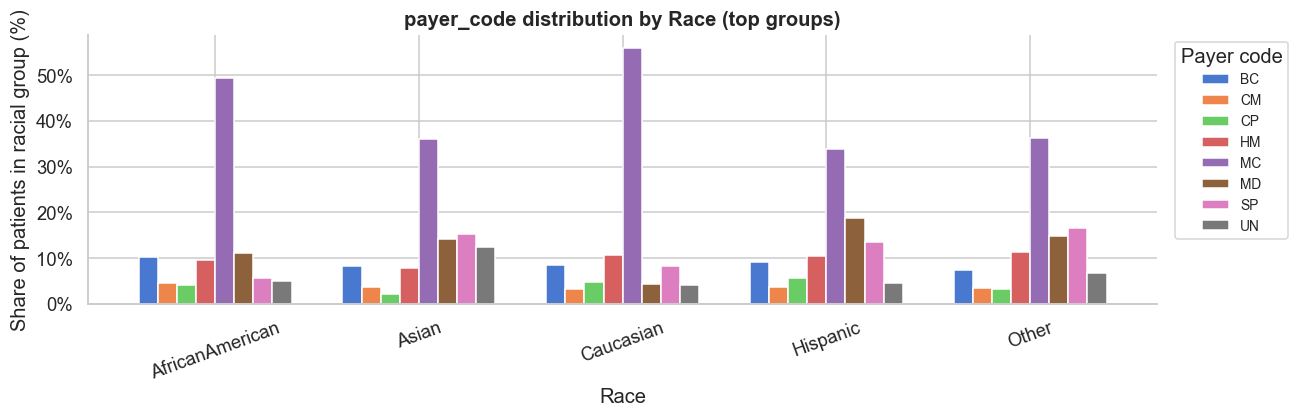


Note: payer_code encodes insurance type. Structural differences in insurance coverage
across racial groups means payer_code acts as a proxy for race.


In [27]:
# payer_code distribution by race
# Filter to top races and top payer codes for readability
top_races = df['race'].value_counts().head(5).index.tolist()
df_races = df[df['race'].isin(top_races)].copy()

top_payers = df['payer_code'].value_counts().head(8).index.tolist()
df_payer = df_races[df_races['payer_code'].isin(top_payers)].copy()

pivot = df_payer.groupby(['race', 'payer_code']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 4))
pivot_pct.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)
ax.set_title('payer_code distribution by Race (top groups)', fontweight='bold')
ax.set_ylabel('Share of patients in racial group (%)')
ax.set_xlabel('Race')
ax.tick_params(axis='x', rotation=20)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Payer code', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_payer_by_race.png', bbox_inches='tight')
plt.show()

print('\nNote: payer_code encodes insurance type. Structural differences in insurance coverage')
print('across racial groups means payer_code acts as a proxy for race.')

In [28]:
# Cramér's V — measure of association between categorical variables
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Compute Cramér's V statistic for two categorical columns."""
    df_clean = pd.DataFrame({'x': x, 'y': y}).dropna()
    contingency = pd.crosstab(df_clean['x'], df_clean['y'])
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

proxy_features = ['payer_code', 'discharge_disposition_id', 'admission_type_id',
                  'admission_source_id', 'num_medications', 'time_in_hospital']

# Association with race
print('=== Cramér\'s V: Association of features WITH RACE ===')
print('(Higher = stronger proxy for race)')
assoc_race = {}
for feat in proxy_features:
    if feat in df.columns:
        try:
            v = cramers_v(df['race'], df[feat].astype(str))
            assoc_race[feat] = round(v, 4)
        except Exception as e:
            assoc_race[feat] = f'Error: {e}'

display(pd.Series(assoc_race, name="Cramér's V").sort_values(ascending=False).to_frame())

=== Cramér's V: Association of features WITH RACE ===
(Higher = stronger proxy for race)


,Cramér's V
payer_code,0.0846
admission_source_id,0.0671
admission_type_id,0.0664
discharge_disposition_id,0.0556
num_medications,0.0509
time_in_hospital,0.0231


### 2.6 Clinical feature distributions by age group

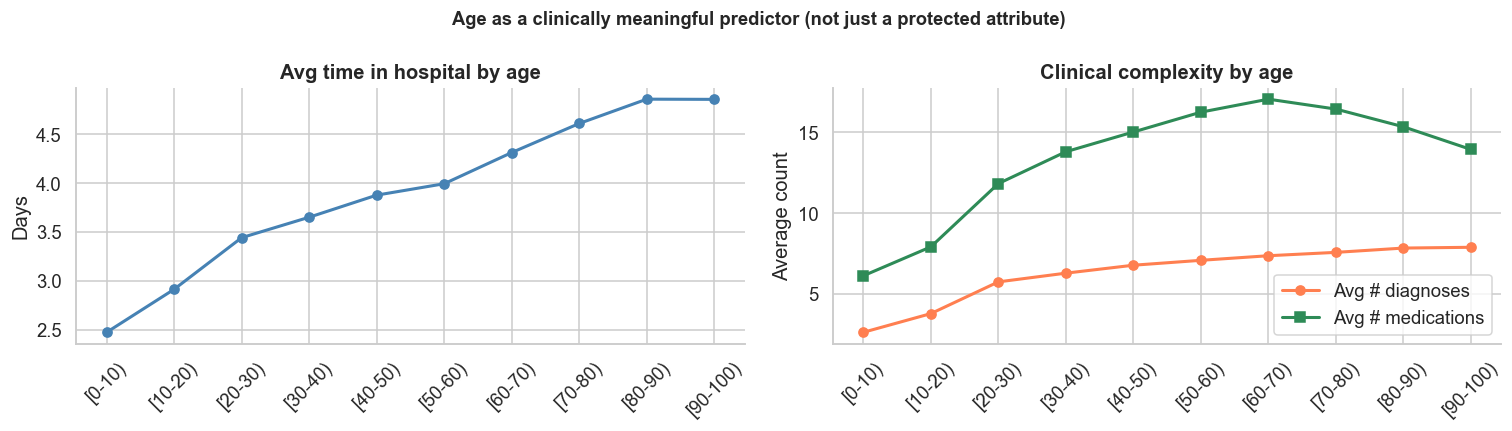

Older patients have more diagnoses, more medications, and longer stays.
This means higher predicted readmission risk for older patients is CLINICALLY GROUNDED.
Naive debiasing by age risks masking a real clinical signal.


In [29]:
# Time in hospital and number_diagnoses vs age — shows why age is a clinically
# meaningful predictor, not just a protected-attribute proxy
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

age_clinical = df.groupby('age', dropna=False)[['time_in_hospital', 'number_diagnoses', 'num_medications']].mean()
age_clinical = age_clinical.reindex(age_order)

axes[0].plot(age_clinical.index, age_clinical['time_in_hospital'],
             marker='o', linewidth=2, color='steelblue', label='Avg days in hospital')
axes[0].set_title('Avg time in hospital by age', fontweight='bold')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(age_clinical.index, age_clinical['number_diagnoses'],
             marker='o', linewidth=2, color='coral', label='Avg # diagnoses')
axes[1].plot(age_clinical.index, age_clinical['num_medications'],
             marker='s', linewidth=2, color='seagreen', label='Avg # medications')
axes[1].set_title('Clinical complexity by age', fontweight='bold')
axes[1].set_ylabel('Average count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Age as a clinically meaningful predictor (not just a protected attribute)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_age_clinical.png', bbox_inches='tight')
plt.show()

print('Older patients have more diagnoses, more medications, and longer stays.')
print('This means higher predicted readmission risk for older patients is CLINICALLY GROUNDED.')
print('Naive debiasing by age risks masking a real clinical signal.')

### 2.7 Historical / Label bias

The readmission label in this dataset comes from **institutional discharge decisions**. This introduces label bias in at least two ways:

1. **Differential follow-up**: Patients with better insurance (correlated with White race) had more follow-up care arranged at discharge. More follow-up → more detected deterioration → more readmissions *recorded*. Uninsured patients may have deteriorated equally but simply not returned or not been able to return.

2. **Differential discharge thresholds**: If clinicians historically discharged Black patients or uninsured patients earlier (due to bed pressure, implicit bias, or payer incentives), those patients may appear "not readmitted" in the data — not because they were healthier, but because they weren't readmitted to *this* hospital system.

This is what Obermeyer et al. (2019) call **label proxy bias** — the label (`readmitted`) is a proxy for the true outcome (deteriorated health) but that proxy is noisier for some groups than others.

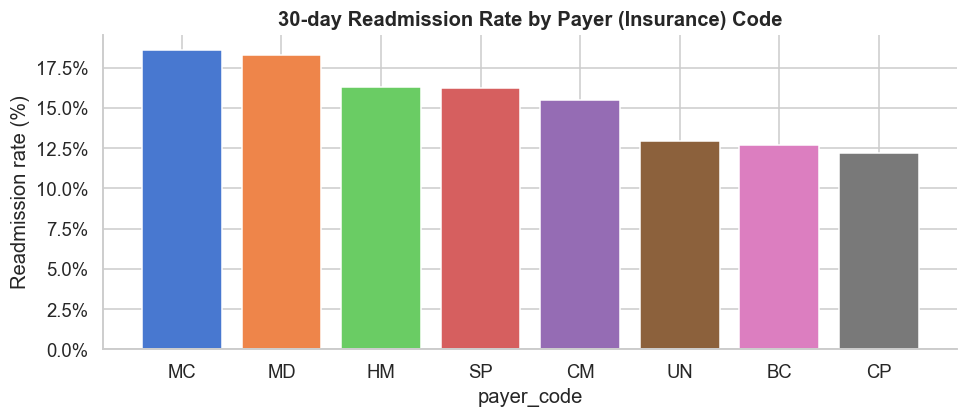


Summary table:


,N,Readmission %
payer_code,,
MC,20457,18.62
MD,2273,18.30
HM,3954,16.29
SP,3138,16.25
CM,1276,15.52
UN,1752,12.96
BC,3354,12.70
CP,1752,12.21


In [30]:
# Readmission rate by payer_code — visualises the insurance/readmission link
payer_readmit = (df[df['payer_code'].isin(top_payers)]
                 .groupby('payer_code')['readmitted_30']
                 .agg(['mean', 'count'])
                 .sort_values('mean', ascending=False))
payer_readmit['mean_pct'] = payer_readmit['mean'] * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(payer_readmit.index, payer_readmit['mean_pct'],
       color=sns.color_palette('muted', len(payer_readmit)), edgecolor='white')
ax.set_title('30-day Readmission Rate by Payer (Insurance) Code', fontweight='bold')
ax.set_ylabel('Readmission rate (%)')
ax.set_xlabel('payer_code')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_payer_readmission.png', bbox_inches='tight')
plt.show()

print('\nSummary table:')
display(payer_readmit[['count', 'mean_pct']].rename(columns={'count': 'N', 'mean_pct': 'Readmission %'}).round(2))

### 2.8 Intersectional analysis preview

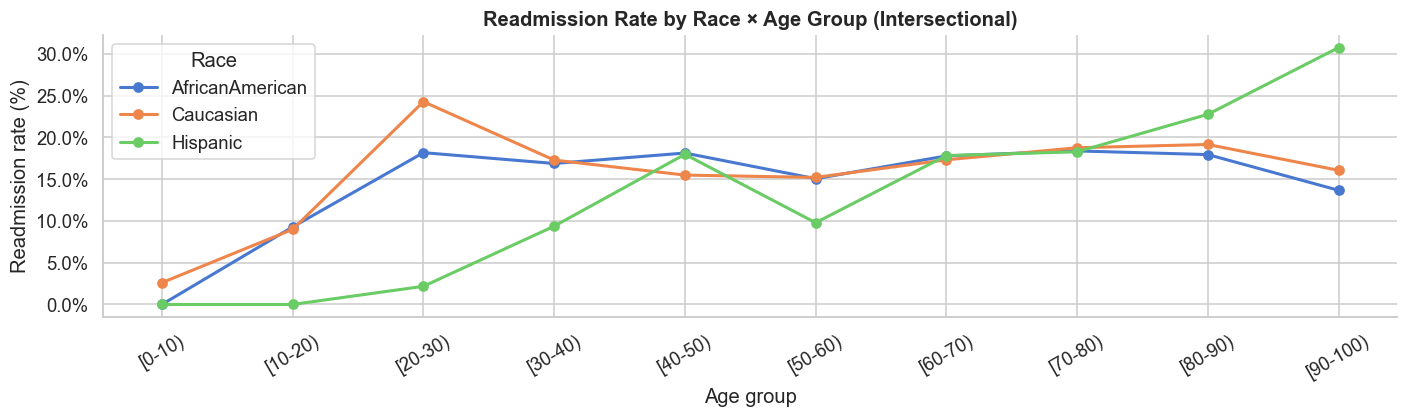


Intersectional readmission rates (%):


age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
race,,,,,,,,,,
AfricanAmerican,0.0,9.3,18.2,16.9,18.1,15.1,17.8,18.4,18.0,13.7
Caucasian,2.6,9.0,24.3,17.3,15.5,15.2,17.3,18.8,19.2,16.1
Hispanic,0.0,0.0,2.2,9.4,18.0,9.8,17.8,18.3,22.8,30.8


In [31]:
# Intersectional readmission rates: Race × Age group (top 3 races for clarity)
top3_races = df['race'].value_counts().head(3).index.tolist()
df_inter = df[df['race'].isin(top3_races)].copy()

pivot_inter = (df_inter.groupby(['race', 'age'])['readmitted_30']
               .mean()
               .unstack('age')
               .reindex(columns=age_order) * 100)

fig, ax = plt.subplots(figsize=(13, 4))
for race in pivot_inter.index:
    ax.plot(age_order, pivot_inter.loc[race], marker='o', linewidth=2, label=race)

ax.set_title('Readmission Rate by Race × Age Group (Intersectional)', fontweight='bold')
ax.set_ylabel('Readmission rate (%)')
ax.set_xlabel('Age group')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Race')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_intersectional.png', bbox_inches='tight')
plt.show()

print('\nIntersectional readmission rates (%):')
display(pivot_inter.round(1))

### 2.9 Summary of bias sources identified

| Bias type | Where found | What it means |
|---|---|---|
| **Representation bias** | Race column: ~75% White, ~19% African American | Model trained on skewed data may generalise poorly to minority groups |
| **Historical / label bias** | Readmission label depends on who could *access* readmission | Black and uninsured patients systematically under-counted as readmitted |
| **Proxy features** | `payer_code` strongly associated with race (Cramér's V) | Even if race is excluded, model can reconstruct it via payer_code |
| **Clinically grounded signal** | Age monotonically predicts more diagnoses, meds, hospital days | Age-related predictions are not purely discriminatory — removing them may harm elderly patients |
| **Structural / societal bias** | African Americans present with more acute illness at admission | Bias source is *upstream* of the model; model alone cannot fix it |

---
**Next notebook:** Section 3 — Baseline model training + per-group fairness metrics

In [32]:
# Save cleaned dataset for use in subsequent notebooks
df.to_csv(f'{DATA_DIR}/diabetes_130_cleaned.csv', index=False)
print(f'Cleaned dataset saved: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('Protected attributes: race, gender, age')
print('Target: readmitted_30 (binary)')

Cleaned dataset saved: 66,221 rows × 48 columns
Protected attributes: race, gender, age
Target: readmitted_30 (binary)
